In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Set style for high-quality charts
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('Mall_Customers.csv')

# Clean column names for easier coding
df.rename(columns={
    'Annual Income (k$)': 'Annual Income', 
    'Spending Score (1-100)': 'Spending Score'
}, inplace=True)

# Display data snapshot and check for missing values
print("--- Dataset Sample ---")
print(df.head())
print("\n--- Missing Values Check ---")
print(df.isnull().sum())

--- Dataset Sample ---
   CustomerID  Gender  Age  Annual Income  Spending Score
0           1    Male   19             15              39
1           2    Male   21             15              81
2           3  Female   20             16               6
3           4  Female   23             16              77
4           5  Female   31             17              40

--- Missing Values Check ---
CustomerID        0
Gender            0
Age               0
Annual Income     0
Spending Score    0
dtype: int64


In [3]:
# Select features for clustering
features = df[['Age', 'Annual Income', 'Spending Score']]

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the features
scaled_features = scaler.fit_transform(features)

print("Features selected and scaled successfully.")
print("Scaled matrix shape:", scaled_features.shape)

Features selected and scaled successfully.
Scaled matrix shape: (200, 3)


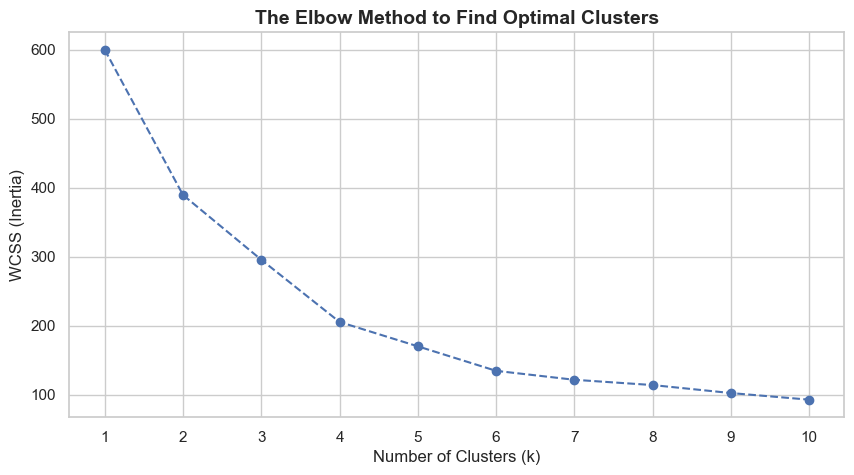

In [4]:
# Calculate WCSS for various cluster counts
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method to Find Optimal Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(range(1, 11))
plt.show()

In [5]:
# Initialize K-Means with 5 clusters
optimal_clusters = 5
kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++', random_state=42)

# Fit the model and predict group labels
df['Cluster'] = kmeans.fit_predict(scaled_features)

print("Model training complete. Cluster labels successfully mapped to original dataset.")
print("\nCustomer counts per segment:")
print(df['Cluster'].value_counts().sort_index())

Model training complete. Cluster labels successfully mapped to original dataset.

Customer counts per segment:
Cluster
0    58
1    40
2    26
3    45
4    31
Name: count, dtype: int64


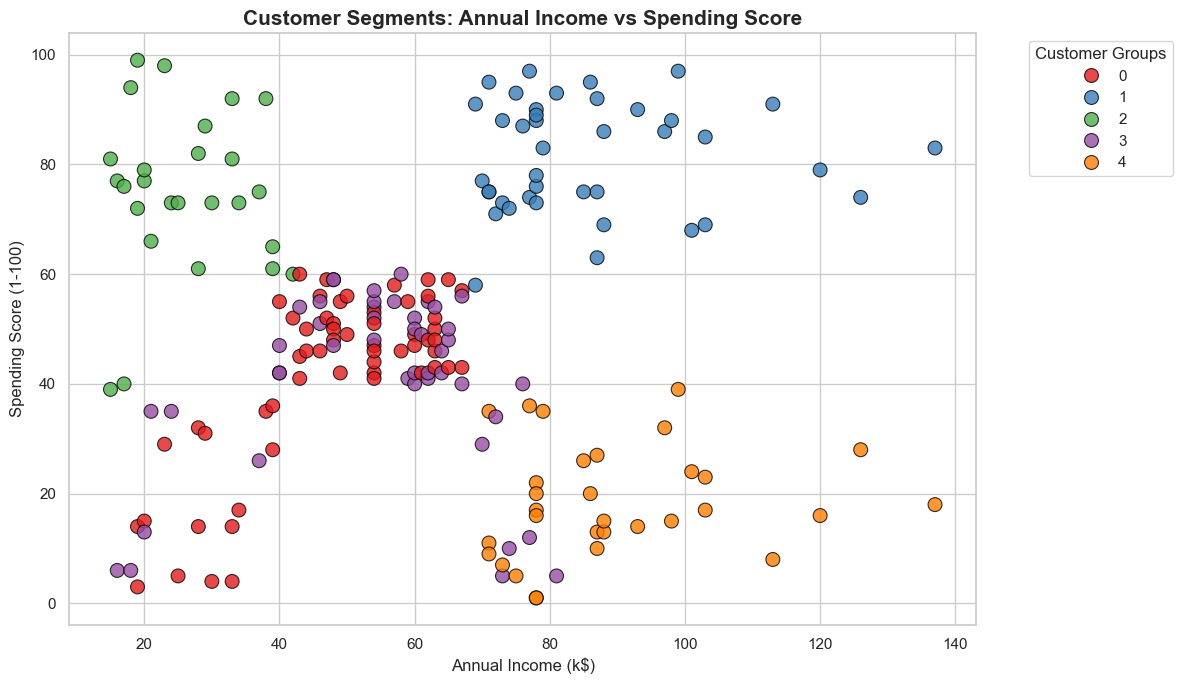

In [6]:
# Plotting the segmented data
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='Annual Income', 
    y='Spending Score', 
    hue='Cluster', 
    palette='Set1', 
    data=df, 
    s=100, 
    edgecolor='black', 
    alpha=0.8
)

plt.title('Customer Segments: Annual Income vs Spending Score', fontsize=15, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(title='Customer Groups', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [8]:
# Calculate statistical averages for each segment
cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income', 'Spending Score']].mean()

print("==================== CUSTOMER SEGMENT PROFILES ====================")
print(cluster_profile.round(2))
print("===================================================================")

print("\n Business Breakdown Quick-Guide:")
print("• Group with High Income & High Spending  --> 'Target Masters' (Focus on Premium/Loyalty Perks)")
print("• Group with High Income & Low Spending   --> 'Conservative High-Earners' (Focus on Value/Quality Campaigns)")
print("• Group with Low Income & High Spending   --> 'Impulsive/Young Spenders' (Focus on Flash Sales/Trends)")
print("• Group with Low Income & Low Spending    --> 'Frugal/Budget Shoppers' (Focus on Essential Discounts)")
print("• Group with Mid Income & Mid Spending    --> 'Average/Consistent Mainstream'")

==================== CUSTOMER SEGMENT PROFILES ====================
           Age  Annual Income  Spending Score
Cluster                                      
0        55.28          47.62           41.71
1        32.88          86.10           81.53
2        25.77          26.12           74.85
3        26.73          54.31           40.91
4        44.39          89.77           18.48

 Business Breakdown Quick-Guide:
• Group with High Income & High Spending  --> 'Target Masters' (Focus on Premium/Loyalty Perks)
• Group with High Income & Low Spending   --> 'Conservative High-Earners' (Focus on Value/Quality Campaigns)
• Group with Low Income & High Spending   --> 'Impulsive/Young Spenders' (Focus on Flash Sales/Trends)
• Group with Low Income & Low Spending    --> 'Frugal/Budget Shoppers' (Focus on Essential Discounts)
• Group with Mid Income & Mid Spending    --> 'Average/Consistent Mainstream'


In [9]:
# Export the dataset with customer tags to a new CSV file
df.to_csv('Customer_Segmentation_Final_Results.csv', index=False)
print("File 'Customer_Segmentation_Final_Results.csv' successfully saved and ready for final project submission!")

File 'Customer_Segmentation_Final_Results.csv' successfully saved and ready for final project submission!
